In [3]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
print(rng)

Generator(PCG64)


## Chapter 08a — Probability

Probability is the mathematics of **uncertainty**. Machine learning is built on
it: data is noisy, models make predictions with confidence, and we constantly
ask *"how likely is this?"*

In this notebook we take a hands-on view. Instead of only proving formulas, we
**simulate** random experiments thousands of times and watch the theory emerge
from the data. The tool for that is NumPy's modern random generator:

```python
rng = np.random.default_rng(0)   # 0 is a "seed" -> reproducible randomness
```

Because we fix the seed, you will get the
exact same "random" numbers every time — which is perfect for learning.

_____
### 1. Sample spaces and events

A random **experiment** has a set of possible outcomes called the **sample
space** $\Omega$. An **event** is a subset $A \subseteq \Omega$ — a collection
of outcomes we care about.

- Toss a coin: $\Omega = \{H, T\}$.
- Roll a die: $\Omega = \{1,2,3,4,5,6\}$. The event "even" is $A = \{2,4,6\}$.

The **probability** of an event is a number $P(A) \in [0,1]$. For a *fair* die
every outcome is equally likely, so

$$P(A) = \frac{|A|}{|\Omega|} = \frac{\text{favourable outcomes}}{\text{total outcomes}}.$$

In [4]:
omega = [1, 2, 3, 4, 5, 6]      # sample space of a die
even  = [x for x in omega if x % 2 == 0]   # the event "even"
print("sample space:", omega)
print("event 'even':", even)
print("P(even) =", len(even) / len(omega))   # 3/6 = 0.5

sample space: [1, 2, 3, 4, 5, 6]
event 'even': [2, 4, 6]
P(even) = 0.5


_____
### 2. Simulating coins and dice

Real probability becomes vivid when we *run the experiment*. The generator can
draw random integers and make random choices for us.

In [5]:
# Toss a fair coin 10 times. 0 = Tails, 1 = Heads.
coins = rng.integers(0, 2, size=10)    # integers in [0, 2) -> 0 or 1
print("coin tosses:", coins)

# Roll a fair die 10 times: integers in [1, 7) -> 1..6
dice = rng.integers(1, 7, size=10)
print("die rolls:  ", dice)

coin tosses: [1 1 1 0 0 0 0 0 0 1]
die rolls:   [4 6 4 4 6 5 4 4 4 6]


______
### 3. Estimating probability by frequency

If we repeat an experiment $N$ times and event $A$ happens $n_A$ times, the
**relative frequency** $n_A / N$ is an *estimate* of $P(A)$:

$$\widehat{P}(A) = \frac{n_A}{N}.$$

Let us estimate $P(\text{roll} \le 2)$, whose true value is $2/6 \approx 0.333$.

In [6]:
N = 100_000
rolls = rng.integers(1, 7, size=N)        # N die rolls

# Count how many satisfy the event, then divide by N.
hits = np.count_nonzero(rolls <= 2)       # number of 1s and 2s
estimate = hits / N
print("estimate of P(roll <= 2):", estimate)
print("true value             :", 2 / 6)

estimate of P(roll <= 2): 0.33245
true value             : 0.3333333333333333


_____
### 4. The Law of Large Numbers

The estimate above was close, but not exact. The **Law of Large Numbers** (LLN)
says: as $N \to \infty$, the relative frequency converges to the true
probability. We can *see* this by plotting the running estimate as we collect
more and more samples.

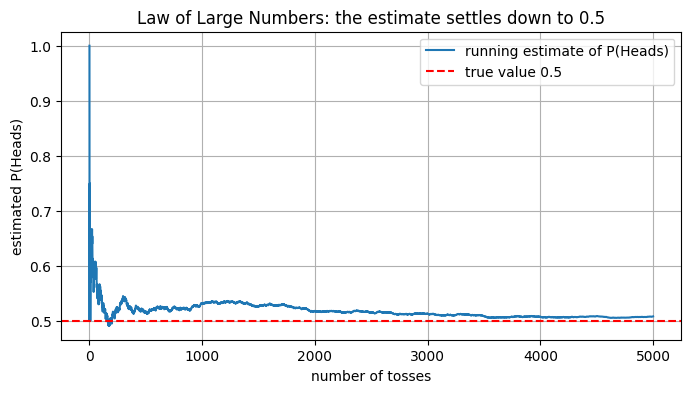

In [7]:
N = 5000
tosses = rng.integers(0, 2, size=N)          # 1 = Heads, 0 = Tails

# np.cumsum gives running totals: [t0, t0+t1, t0+t1+t2, ...]
running_heads = np.cumsum(tosses)            # cumulative number of heads
trial_number  = np.arange(1, N + 1)          # 1, 2, 3, ..., N
running_estimate = running_heads / trial_number   # estimate after each toss

plt.figure(figsize=(8, 4))
plt.plot(trial_number, running_estimate, label="running estimate of P(Heads)")
plt.axhline(0.5, color="red", linestyle="--", label="true value 0.5")
plt.xlabel("number of tosses")
plt.ylabel("estimated P(Heads)")
plt.title("Law of Large Numbers: the estimate settles down to 0.5")
plt.legend()
plt.grid(True)
plt.show()

Early on the estimate jumps around wildly; with more data it locks onto $0.5$.
That settling-down is the LLN in action — and it is *why* averaging over lots of
data works in machine learning.

_____
### 5. Random variables

A **random variable** $X$ assigns a number to each outcome. For one die,
$X$ = the face shown. We can describe $X$ by its **distribution**: the
probability of each value. For a fair die, $P(X = k) = 1/6$ for $k = 1,\dots,6$.

In [8]:
N = 60_000
X = rng.integers(1, 7, size=N)  # random

faces = np.arange(1, 7)
counts = np.array([np.count_nonzero(X == k) for k in faces])
probs = counts / N
for k, p in zip(faces, probs):
    print(f"P(X = {k} estimated as {p:.4f})")

P(X = 1 estimated as 0.1668)
P(X = 2 estimated as 0.1635)
P(X = 3 estimated as 0.1698)
P(X = 4 estimated as 0.1678)
P(X = 5 estimated as 0.1654)
P(X = 6 estimated as 0.1667)


Key idea: The estimated probabilities will usually differ slightly from \(1/6\) for each face, but with more rolls, they generally tend to get closer to the true probability.

_____
### 6. Expectation and variance

The **expectation** (mean) of $X$ is the long-run average value, weighting each
possible value by its probability:

$$\mathbb{E}[X] = \sum_k k \, P(X = k).$$

The **variance** measures spread around the mean:

$$\operatorname{Var}(X) = \mathbb{E}\big[(X - \mathbb{E}[X])^2\big].$$

For a fair die the theory gives $\mathbb{E}[X] = 3.5$ and
$\operatorname{Var}(X) = 35/12 \approx 2.9167$. Let us check both against a big
sample — the sample mean and sample variance are estimates of these.

In [9]:
# Theoretical values from the definition (sum over k of k * P(X=k)):
k = np.arange(1, 7)
p = np.full(6, 1/6)                 # uniform probabilities 1/6 each
EX_theory  = np.sum(k * p)                       # expectation
VarX_theory = np.sum((k - EX_theory)**2 * p)     # variance
print("theory : E[X] =", EX_theory, " Var(X) =", VarX_theory)

# Estimates from samples: np.mean and np.var do exactly the averaging above.
X = rng.integers(1, 7, size=200_000)
print("sample : E[X] =", np.mean(X), " Var(X) =", np.var(X))

theory : E[X] = 3.5  Var(X) = 2.9166666666666665
sample : E[X] = 3.49866  Var(X) = 2.913118204400001


_____
### 7. Independence

Two events $A$ and $B$ are **independent** if one happening tells us nothing
about the other:

$$P(A \cap B) = P(A)\,P(B).$$

Two separate dice are independent. Let $A$ = "first die is 6" and
$B$ = "second die is 6". Then $P(A) = P(B) = 1/6$, so
$P(A \cap B) = 1/36 \approx 0.0278$.

In [10]:
N = 200_000
die1 = rng.integers(1, 7, size=N)
die2 = rng.integers(1, 7, size=N)

PA  = np.mean(die1 == 6)                 # estimate P(A)
PB  = np.mean(die2 == 6)                 # estimate P(B)
PAB = np.mean((die1 == 6) & (die2 == 6)) # estimate P(A and B)

print("P(A)        :", PA)
print("P(B)        :", PB)
print("P(A and B)  :", PAB)
print("P(A)*P(B)   :", PA * PB, "  <- matches, so A and B are independent")

P(A)        : 0.166975
P(B)        : 0.16769
P(A and B)  : 0.028
P(A)*P(B)   : 0.02800003775   <- matches, so A and B are independent


____
### ✍️ Exercise 1 (solution included)

Estimate the probability that the **sum of two dice equals 7** by simulating
$200{,}000$ rolls of a pair of dice. Compare with the true value $6/36 = 1/6$.

In [11]:
N = 200_000
d1 = rng.integers(1, 7, size=N)
d2 = rng.integers(1, 7, size=N)
totals = d1 + d2                          # elementwise sum of the two dice

estimate = np.mean(totals == 7)           # fraction of rolls summing to 7
print("estimate of P(sum = 7):", estimate)
print("true value            :", 6 / 36)

estimate of P(sum = 7): 0.166555
true value            : 0.16666666666666666


______
### ✍️ Exercise 2 (solution included)

A random variable $Y$ is the **maximum** of two dice. Estimate $\mathbb{E}[Y]$
from $200{,}000$ samples. (For reference, the exact answer is
$\tfrac{161}{36} \approx 4.472$.)

In [12]:
N = 200_000
d1 = rng.integers(1, 7, size=N)
d2 = rng.integers(1, 7, size=N)
Y = np.maximum(d1, d2)                     # elementwise maximum

print("estimated E[Y]:", np.mean(Y))
print("exact value   :", 161 / 36)

estimated E[Y]: 4.47736
exact value   : 4.472222222222222


### 8. Conditional probability and Bayes' rule

The probability of $A$ **given** that $B$ happened is

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}.$$

Rearranging gives **Bayes' rule**, the engine of probabilistic reasoning:

$$P(A \mid B) = \frac{P(B \mid A)\, P(A)}{P(B)}.$$

### A worked example: a medical test

A disease affects $1\%$ of people: $P(D) = 0.01$. A test is good but not
perfect:

- if you **have** the disease it tests positive $99\%$ of the time:
  $P(+\mid D) = 0.99$ (the *sensitivity*);
- if you are **healthy** it still falsely tests positive $5\%$ of the time:
  $P(+\mid \neg D) = 0.05$ (the *false-positive rate*).

**Question:** you test positive. What is $P(D \mid +)$, the chance you actually
have the disease? Most people guess "about 99%". Bayes says otherwise.

In [14]:
# Prior and likelihoods
P_D     = 0.01     # P(disease)
P_pos_D = 0.99     # P(+ | disease)
P_pos_nD = 0.05    # P(+ | no disease)

# Total probability of a positive test:
#   P(+) = P(+|D)P(D) + P(+|~D)P(~D)
P_pos = P_pos_D * P_D + P_pos_nD * (1 - P_D)

# Bayes' rule
P_D_given_pos = (P_pos_D * P_D) / P_pos
print("P(disease | positive test) =", round(P_D_given_pos, 4))

P(disease | positive test) = 0.1667


Only about **16.7%**! Because the disease is rare, the *many* false positives
from healthy people outnumber the true positives. Let us **verify by
simulation**: create a big population, give each person a true disease status,
run the noisy test, then look only at those who tested positive.

In [15]:
N = 1_000_000

# Step 1: who actually has the disease? True with probability 0.01.
has_disease = rng.random(N) < P_D          # rng.random gives uniform [0,1)

# Step 2: run the test. Sick people: positive w.p. 0.99; healthy: w.p. 0.05.
test_prob = np.where(has_disease, P_pos_D, P_pos_nD)
tested_positive = rng.random(N) < test_prob

# Step 3: among the positives, what fraction truly have the disease?
positives = np.count_nonzero(tested_positive)
true_and_positive = np.count_nonzero(has_disease & tested_positive)
print("simulated P(disease | positive):", round(true_and_positive / positives, 4))
print("Bayes formula gave            :", round(P_D_given_pos, 4))

simulated P(disease | positive): 0.165
Bayes formula gave            : 0.1667
